# Importing packages

In [1]:
import scimap as sm
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy as sp
import os
import yaml
from pathlib import Path
from matplotlib import colormaps
import seaborn as sns

Running SCIMAP  2.1.3


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [2]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
results_dir = Path(config['results_dir'])

In [3]:
adata = ad.read_h5ad(results_dir / "adata.h5ad")
sc.pp.scale(adata)

In [4]:
#correct for batch effects
sc.pp.scale(adata)
sc.pp.combat(adata, key="run")
adata.X = adata.X.astype(np.float32).copy()

In [4]:
adata = sm.tl.spatial_distance(adata, x_coordinate='Cell Center X', y_coordinate='Cell Center Y',
                         phenotype='cell_type', label='2D_distance', imageid="exp_name")

Processing Image: Run141_ROI11
Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run145_ROI3
Processing Image: Run141_ROI19
Processing Image: Run141_ROI1
Processing Image: Run141_ROI8
Processing Image: Run141_ROI17
Processing Image: Run145_ROI10
Processing Image: Run145_ROI11
Processing Image: Run141_ROI15
Processing Image: Run145_ROI1
Processing Image: Run141_ROI4
Processing Image: Run141_ROI23
Processing Image: Run141_ROI3
Processing Image: Run145_ROI9
Processing Image: Run141_ROI14


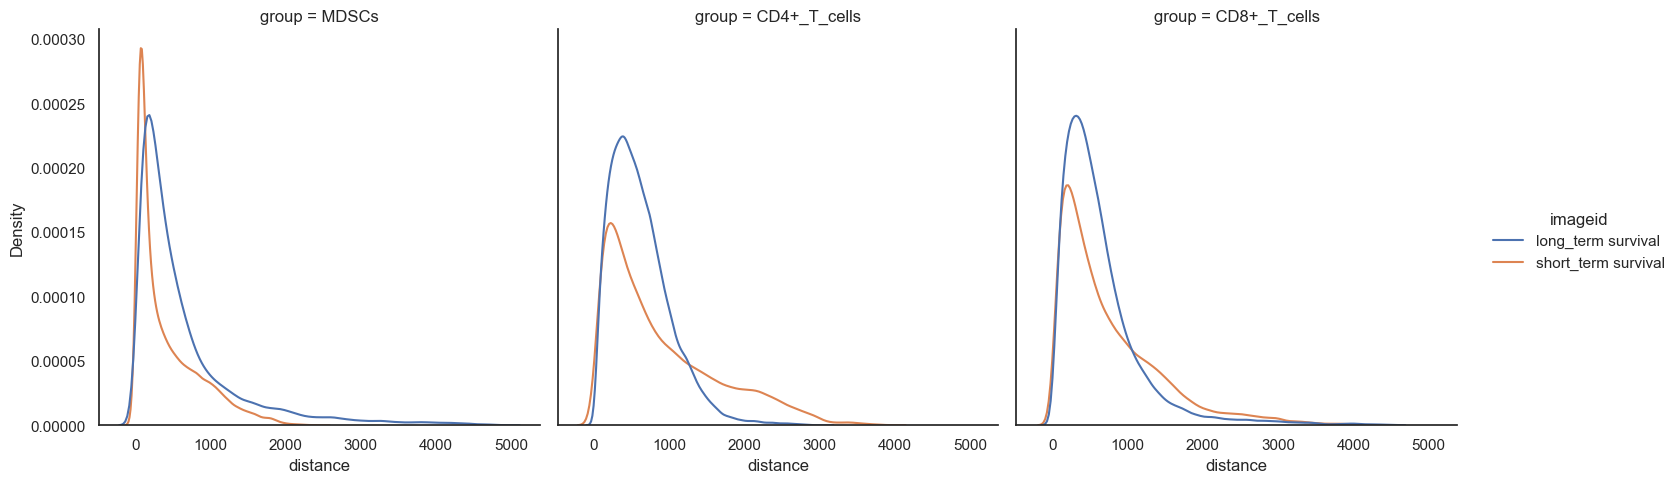

In [99]:
sm.pl.spatial_distance(adata, spatial_distance="2D_distance", phenotype="cell_type", imageid="outcome_group", distance_from="Tumor_cells", method="distribution", distance_to=["MDSCs", "CD4+_T_cells", "CD8+_T_cells"], log=False)

In [5]:
#sort adata by patient ID
adata = adata[adata.obs["patient_ID"].sort_values().index]

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1295: FutureWarning:

In a future version of AnnData, access to `.X` by passing `layer='X'` will be removed. Instead pass `layer=None`.



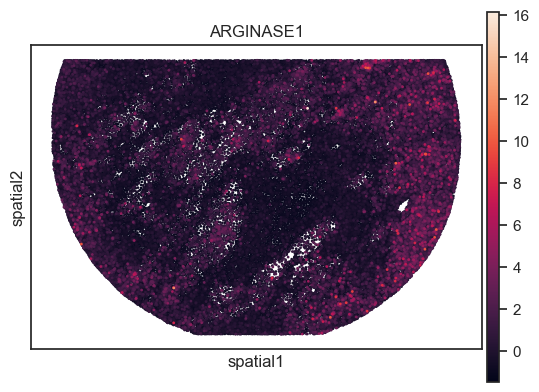

In [6]:
adata_select = adata[adata.obs.exp_name == "Run141_ROI4"]
site = adata_select.obs.site.unique()[0]
sc.pl.spatial(adata_select, color="ARGINASE1", spot_size=100, layer="X")

## How interactions are similar across all sampless

## Spatial distances

In [64]:
adata = sm.tl.spatial_distance(adata, x_coordinate='Cell Center X', y_coordinate='Cell Center Y',
                               phenotype='cell_type', 
                               label='2D_distance',
                               imageid="exp_name")

Processing Image: Run141_ROI11
Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run145_ROI3
Processing Image: Run141_ROI19
Processing Image: Run141_ROI1
Processing Image: Run141_ROI8
Processing Image: Run141_ROI17
Processing Image: Run145_ROI10
Processing Image: Run145_ROI11
Processing Image: Run141_ROI15
Processing Image: Run145_ROI1
Processing Image: Run141_ROI4
Processing Image: Run141_ROI23
Processing Image: Run141_ROI3
Processing Image: Run145_ROI9
Processing Image: Run141_ROI14


In [80]:
adata.uns

OrderedDict([('outcome_group_colors', ['#4c72b0', '#dd8452']),
             ('2D_distance',
                               NFC  Tumor_cells  Actin+_cells  CD8+_T_cells  M1_macrophages  \
              0          48.411425    40.051016    331.968257   3677.976437      379.905720   
              1          80.897073    27.988594    252.282599   3602.512312      395.873805   
              2         107.377732    27.988594    224.303203   3575.073394      400.333410   
              3         450.824560    43.215335    294.653644   2362.250069     1116.408768   
              4         426.687919    34.520335    251.683927   2320.049157     1122.155196   
              ...              ...          ...           ...           ...             ...   
              11341-15  271.360715  1644.578584    363.113868   3351.756381     1179.783288   
              11342-15  390.634744   608.788223     53.965350   2215.437572      972.342456   
              11343-15  548.767366   632.754062     5

In [ ]:
sm.pl.spatial_distance(adata, phenotype='cell_type', imageid='outcome_group', spatial_distance="2D_distance", method="numeric", heatmap_summarize=False, distance_from="Tumor_cells", distance_to=["MDSCs", "CD4+_T_cells", "CD8+_T_cells", "Granulocytes"], log=True, y_axis='distance', x_axis='group', plot_type="swarm")

KeyboardInterrupt: 

## Spatial LDA

In [5]:
sm.tl.spatial_lda(adata, 
                  x_coordinate='Cell Center X', 
                  y_coordinate='Cell Center Y',
                  phenotype="cell_type", 
                  method='knn', 
                  knn=15, 
                  imageid='exp_name', 
                  num_motifs=10, 
                  label='spatial_lda')

Processing: ['Run141_ROI11']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI16']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI7']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run145_ROI3']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI19']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI1']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI8']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI17']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run145_ROI10']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run145_ROI11']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run103_ROI5']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI15']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run145_

AnnData object with n_obs × n_vars = 483504 × 48
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', '

In [6]:
adata

AnnData object with n_obs × n_vars = 483504 × 48
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', '

In [10]:
sm.tl.spatial_cluster(adata, df_name='spatial_lda', method='kmeans', k=6, label='spatial_lda_kmeans')

Kmeans clustering


AnnData object with n_obs × n_vars = 428089 × 61
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', '

TypeError: object of type 'list_reverseiterator' has no len()

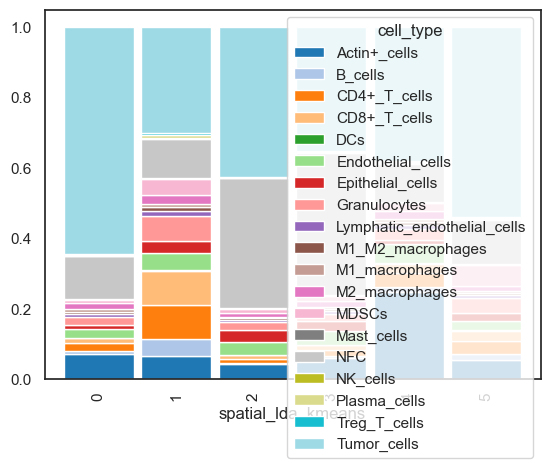

In [11]:
sm.pl.stacked_barplot(adata, x_axis='spatial_lda_kmeans', y_axis='cell_type')

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



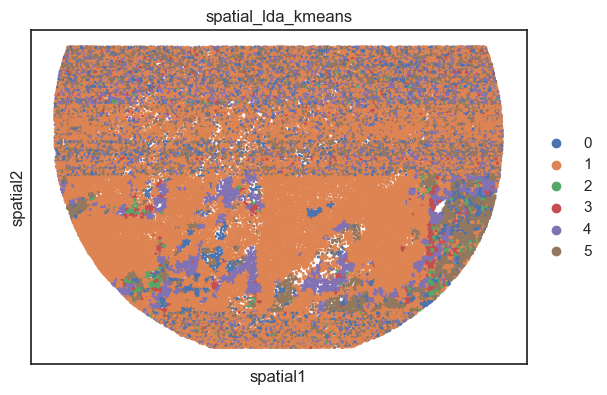

In [17]:
adata_select = adata[adata.obs.exp_name == "Run141_ROI4"]
sc.pl.spatial(adata_select, color="spatial_lda_kmeans", spot_size=100)

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_5009/2237259650.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



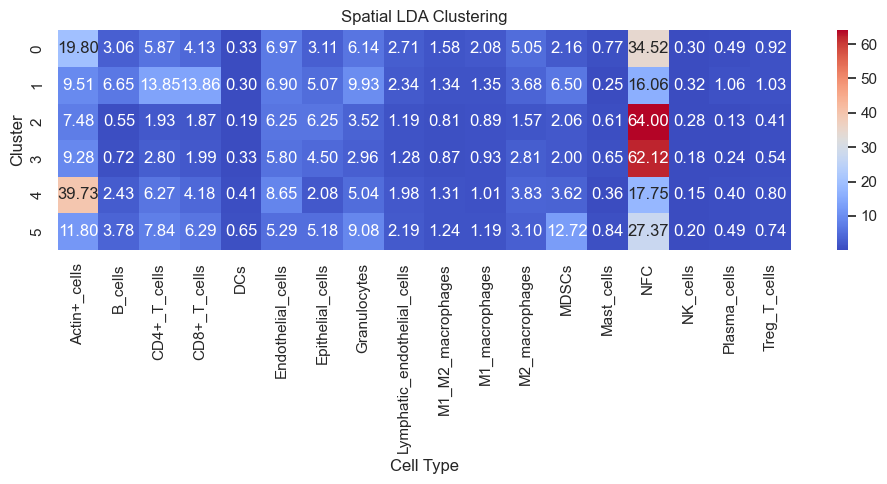

In [12]:
counts = adata.obs.groupby(["spatial_lda_kmeans", "cell_type"]).size().unstack().fillna(0)
counts = counts.drop(columns="Tumor_cells")
counts = counts.div(counts.sum(axis=1), axis=0).mul(100)
plt.figure(figsize=(10, 5))
sns.heatmap(counts, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Spatial LDA Clustering")
plt.xlabel("Cell Type") 
plt.ylabel("Cluster")
plt.tight_layout()

In [8]:
sm.tl.spatial_interaction (adata,
                         x_coordinate='Cell Center X',
                         y_coordinate='Cell Center Y',
                         phenotype="cell_type",
                         method='delaunay',
                         permutation=300,
                         imageid='exp_name',
                         subset=None,
                         pval_method='zscore',
                         normalization='conditional',
                         verbose=True,
                         label='scimap_delaunay_conditional_zscore')

Processing Image: ['Run141_ROI11']
Categories (1, object): ['Run141_ROI11']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI16']
Categories (1, object): ['Run141_ROI16']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI7']
Categories (1, object): ['Run141_ROI7']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run145_ROI3']
Categories (1, object): ['Run145_ROI3']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run1

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['Run145_ROI11']
Categories (1, object): ['Run145_ROI11']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['Run103_ROI5']
Categories (1, object): ['Run103_ROI5']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI15']
Categories (1, object): ['Run141_ROI15']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run145_ROI1']
Categories (1, object): ['Run145_ROI1']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI4']
Categories (1, object): ['Run141_ROI4']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['Run141_ROI23']
Categories (1, object): ['Run141_ROI23']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI3']
Categories (1, object): ['Run141_ROI3']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run145_ROI9']
Categories (1, object): ['Run145_ROI9']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI14']
Categories (1, object): ['Run141_ROI14']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permut

AnnData object with n_obs × n_vars = 483504 × 48
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', '

In [43]:
heatmap_data = adata.uns['scimap_delaunay_conditional_zscore']
heatmap_data.index = heatmap_data["phenotype"] + "-" + heatmap_data["neighbour_phenotype"]
heatmap_data= heatmap_data.drop(columns=["phenotype", "neighbour_phenotype"])
heatmap_data = heatmap_data.filter(like='zscore', axis=1)
heatmap_data.columns = heatmap_data.columns.str.replace('zscore_', '')  # remove zscore_ from column names
ordered_columns = adata.obs.sort_values(by = "outcome_group").loc[:,["exp_name", "patient_ID", "outcome_group"]].drop_duplicates().reset_index(drop=True)
heatmap_data = heatmap_data[ordered_columns["exp_name"]]
heatmap_data.columns = ordered_columns["patient_"].values
#filter out the tumor cells
heatmap_data = heatmap_data.filter(like = "Tumor_cells-", axis=0)
#remove index with Tumor_cells-Tumor-cells
heatmap_data = heatmap_data.drop(index = "Tumor_cells-Tumor_cells")
heatmap_data = heatmap_data.drop(index = "Tumor_cells-Epithelial_cells")



In [44]:
long = adata.obs[adata.obs["outcome_group"] == "long_term survival"].patient_ID.unique()
short = adata.obs[adata.obs["outcome_group"] == "short_term survival"].patient_ID.unique()

In [45]:
boxplot_data = heatmap_data.T
boxplot_data.insert(0, "patient_ID", boxplot_data.index)
boxplot_data["outcome_group"] = np.where(boxplot_data["patient_ID"].isin(long), "long_term survival", "short_term survival")
boxplot_data.drop(columns="patient_ID", inplace=True)
#pivot longer the data
boxplot_data = pd.melt(boxplot_data, id_vars="outcome_group", var_name="interaction", value_name="zscore")
boxplot_data

,outcome_group,interaction,zscore
0,long_term survival,Tumor_cells-Actin+_cells,23.938943
1,long_term survival,Tumor_cells-Actin+_cells,44.939738
2,long_term survival,Tumor_cells-Actin+_cells,61.285113
3,long_term survival,Tumor_cells-Actin+_cells,16.911018
4,long_term survival,Tumor_cells-Actin+_cells,33.238238
...,...,...,...
335,short_term survival,Tumor_cells-Treg_T_cells,-0.794658
336,short_term survival,Tumor_cells-Treg_T_cells,14.549595
337,short_term survival,Tumor_cells-Treg_T_cells,7.391726
338,short_term survival,Tumor_cells-Treg_T_cells,4.002354


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_3782/3906809467.py:10: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:.25'` for the same effect.




Text(0.5, -220.125, 'Patient ID')

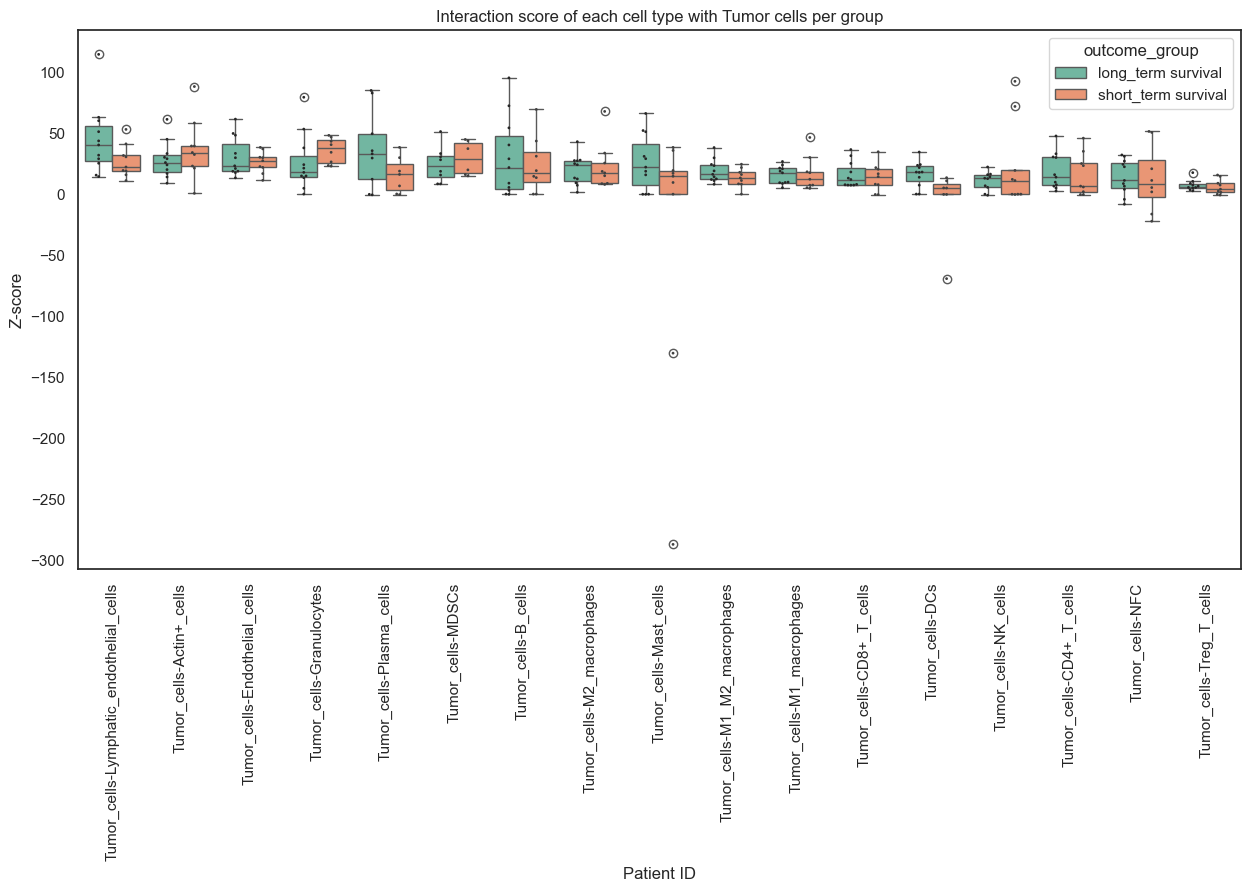

In [47]:
#plot the boxplot of 
plt.figure(figsize=(15, 7))
#add the jitter to the boxplot
#arrange boxplot in decreasing order
order = boxplot_data.groupby("interaction")["zscore"].median().sort_values(ascending=False).index
sns.boxplot(x="interaction", y="zscore", hue="outcome_group",data=boxplot_data, palette="Set2", order=order)
#calculate the pvalue)
plt.xticks(rotation=90)
plt.title("Tumor_cells Interaction")
sns.swarmplot(x="interaction", y="zscore", data=boxplot_data, color=".25", hue="outcome_group", dodge=True, legend=False, size=2)
plt.xticks(rotation=90)
plt.title("Interaction score of each cell type with Tumor cells per group")
plt.ylabel("Z-score")
plt.xlabel("Patient ID")


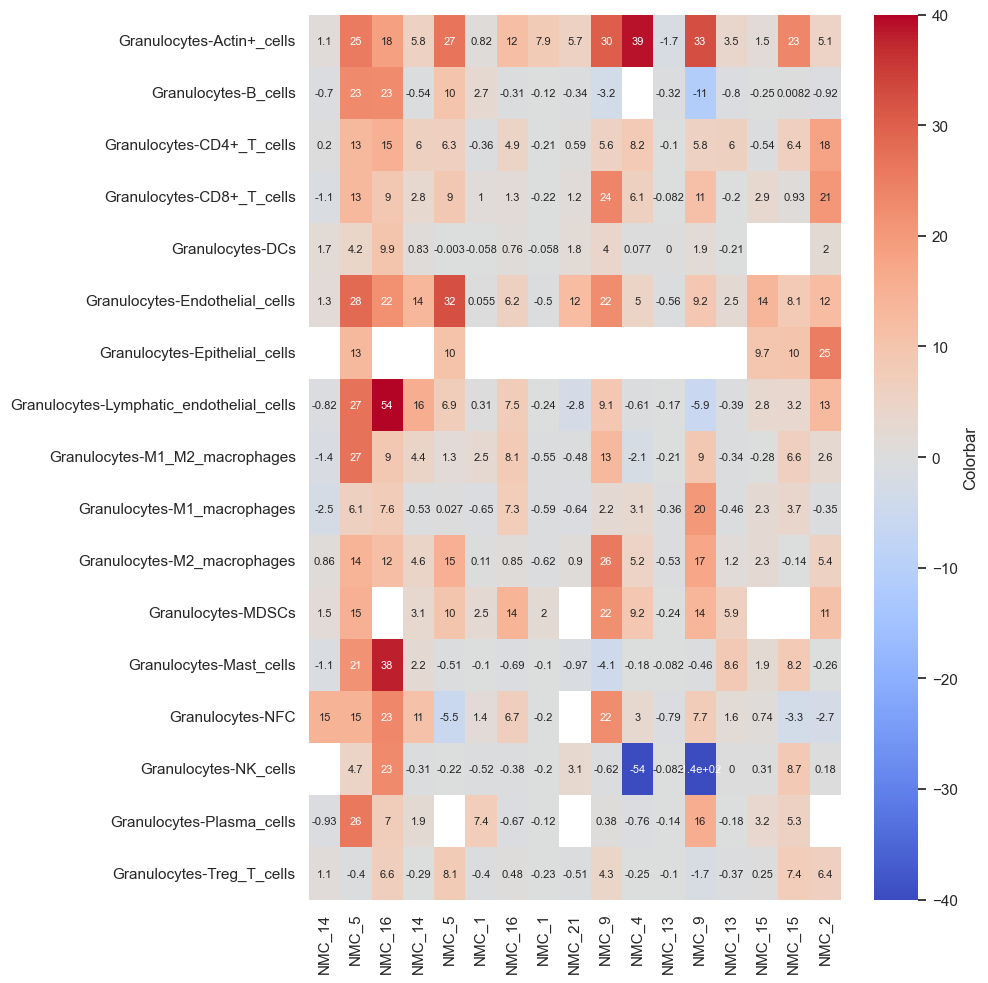

In [19]:
plt.figure(figsize=(10, 10))

# Plot the heatmap
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='coolwarm',
    annot_kws={"size": 8},
    cbar_kws={'label': 'Colorbar'},  # Optional, for better colorbar label
    vmin=-40,
    vmax=40
)

# Rotate row labels for better readability
plt.yticks(rotation=0)  # You can adjust this angle as needed (0 for horizontal)

# Adjust layout for better spacing
plt.tight_layout()

plt.show()

PosixPath('/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed')

In [24]:
adata.obs.loc[:, ["outcome_group", "exp_name", "site"]].drop_duplicates()

,outcome_group,exp_name,site
0,long_term survival,Run141_ROI11,extrahepatic bile ducts
0-1,short_term survival,Run141_ROI16,lung
0-2,short_term survival,Run141_ROI7,lung
0-3,long_term survival,Run141_ROI19,"cervical, A. carotis int. right"
0-4,short_term survival,Run141_ROI1,lung hilus right
0-5,long_term survival,Run141_ROI8,extrahepatic bile ducts
0-6,long_term survival,Run141_ROI17,"cervical, A. carotis int. right"
0-7,short_term survival,Run141_ROI15,"sample: metastasis left tigh, skin \nprimary s..."
0-8,short_term survival,Run141_ROI4,central left lung
0-9,short_term survival,Run141_ROI23,"intrathoracic, right bronchus"


In [12]:
cell_colors = {
    "Tumor_cells": "#FF6347",  # Tomato red
    "Actin+_cells": "grey",  # Steel blue
    "CD8+_T_cells": "#32CD32",  # Lime green
    "M1_macrophages": "#FFD700",  # Gold
    "Treg_T_cells": "#8A2BE2",  # Blue violet
    "M2_macrophages": "#00FA9A",  # Medium spring green
    "DCs": "#FF4500",  # Orange red
    "Endothelial_cells": "#2E8B57",  # Sea green
    "CD4+_T_cells": "#9932CC",  # Dark orchid
    "Mast_cells": "#DAA520",  # Goldenrod
    "Lymphatic_endothelial_cells": "#A52A2A",  # Brown
    "Granulocytes": "#C71585",  # Medium violet red
    "M1_M2_macrophages": "#D2691E",  # Chocolate
    "Plasma_cells": "#8B0000",  # Dark red
    "B_cells": "#4169E1",  # Royal blue
    "MDSCs": "#B22222",  # Firebrick
    "Epithelial_cells": "#228B22",  # Forest green
    "NK_cells": "#FF1493"  # Deep pink
}

In [56]:
adata.obs.outcome_group

0           long_term survival
1           long_term survival
2           long_term survival
3           long_term survival
4           long_term survival
                  ...         
16649-6    short_term survival
16650-6    short_term survival
16651-6    short_term survival
16652-6    short_term survival
16653-6    short_term survival
Name: outcome_group, Length: 179902, dtype: category
Categories (2, object): ['long_term survival', 'short_term survival']

In [13]:
long_term = adata.obs[adata.obs["outcome_group"] == "long_term survival"].exp_name.unique().astype(str)
short_term = adata.obs[adata.obs["outcome_group"] == "short_term survival"].exp_name.unique().astype(str)

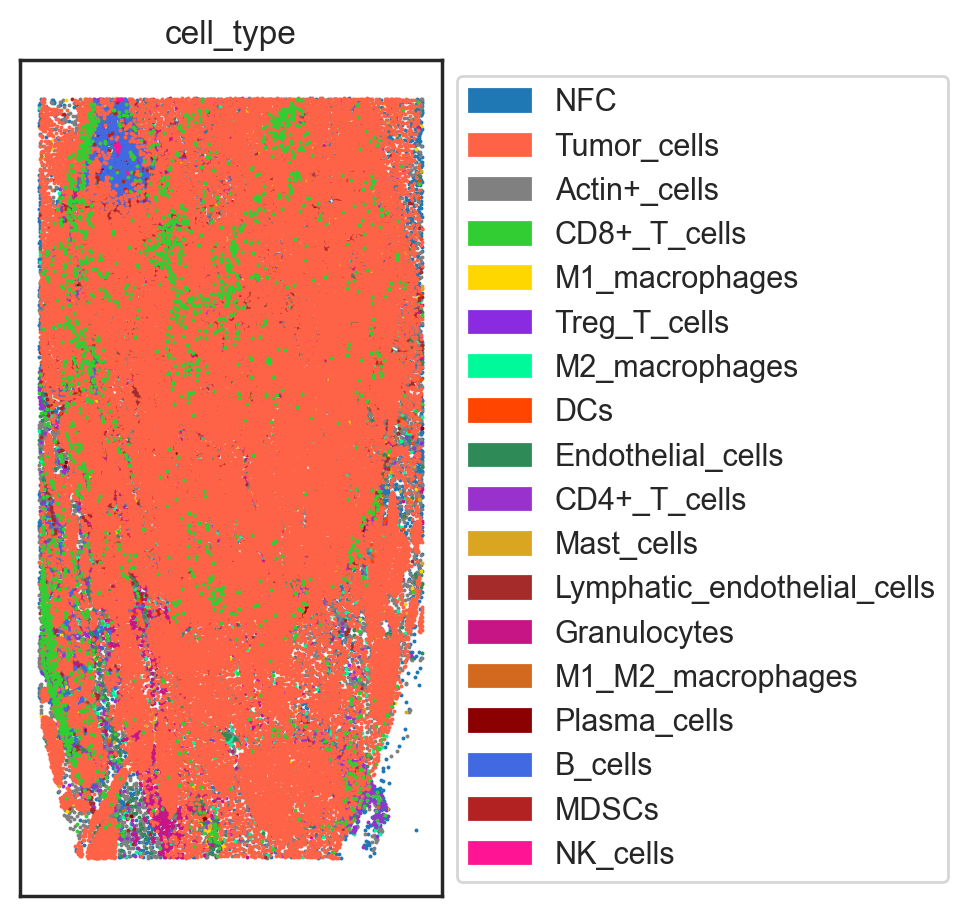

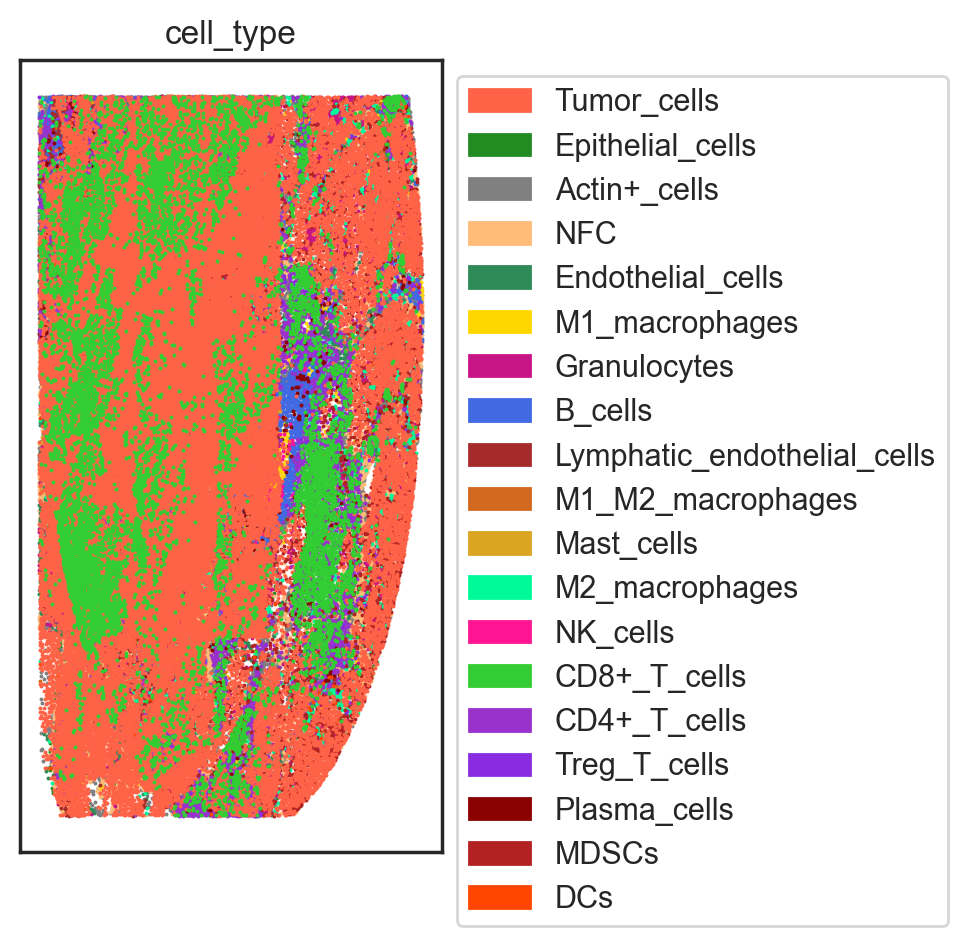

In [15]:
sm.pl.spatial_scatterPlot(adata, colorBy="cell_type", x_coordinate="Cell Center X", y_coordinate="Cell Center Y", topLayer=["Tumor_cells", "CD8+_T_cells"], s=2, subset=long_term, imageid="exp_name", customColors=cell_colors)
sm.pl.spatial_scatterPlot(adata, colorBy="cell_type", x_coordinate="Cell Center X", y_coordinate="Cell Center Y", topLayer=["Tumor_cells", "CD8+_T_cells"], s=2, subset=short_term, imageid="exp_name", customColors=cell_colors)


In [96]:
ordered_columns

['zscore_Run141_ROI11',
 'zscore_Run141_ROI19',
 'zscore_Run141_ROI8',
 'zscore_Run141_ROI17',
 'zscore_Run141_ROI16',
 'zscore_Run141_ROI7',
 'zscore_Run141_ROI15',
 'zscore_Run141_ROI23']

TypeError: object of type 'list_reverseiterator' has no len()

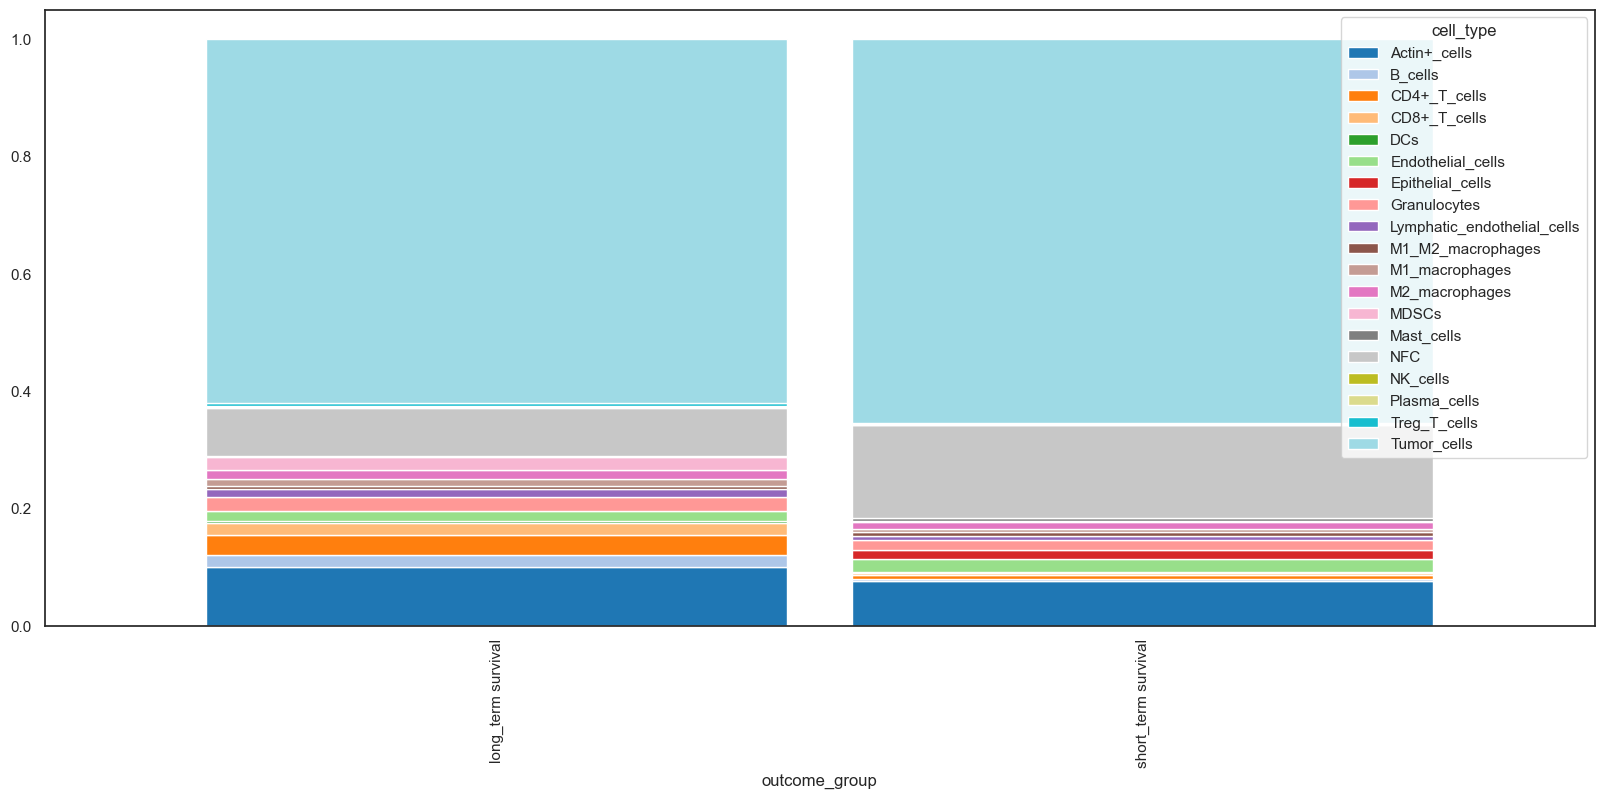

In [115]:
sm.pl.stacked_barplot(adata, x_axis="outcome_group", y_axis="cell_type", method="percent", plot_tool='matplotlib', matplotlib_legend_loc=3, figsize=(20, 8))

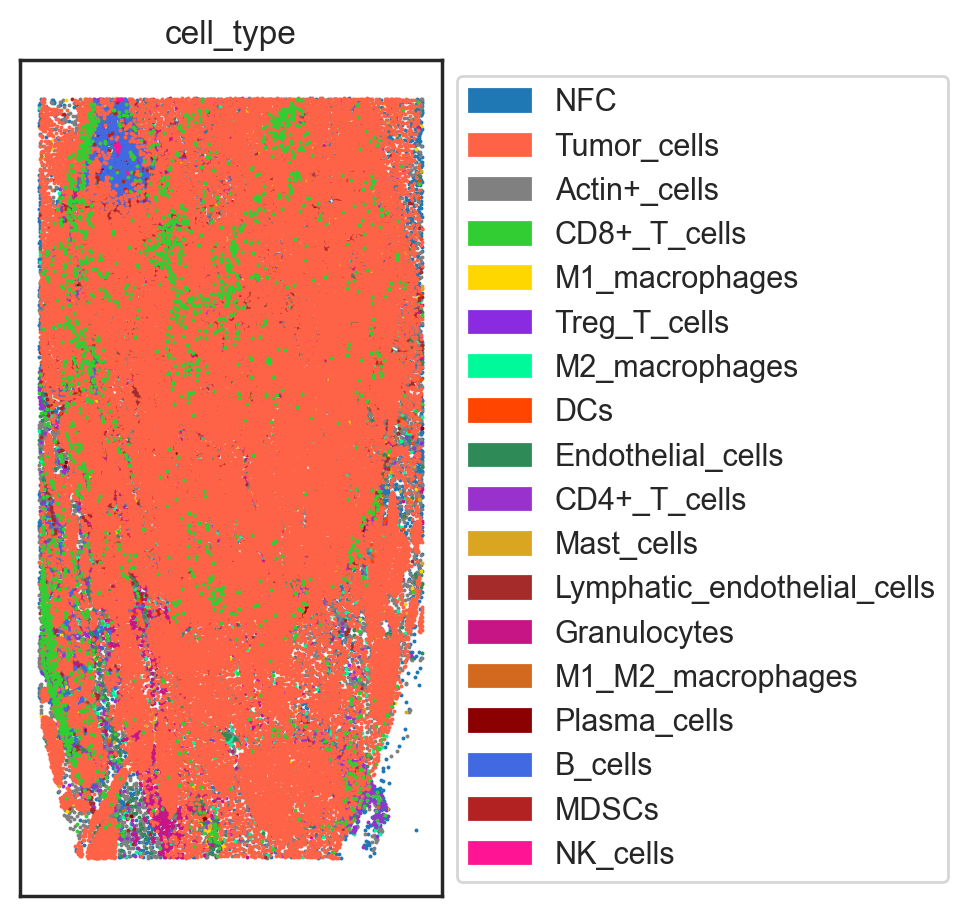

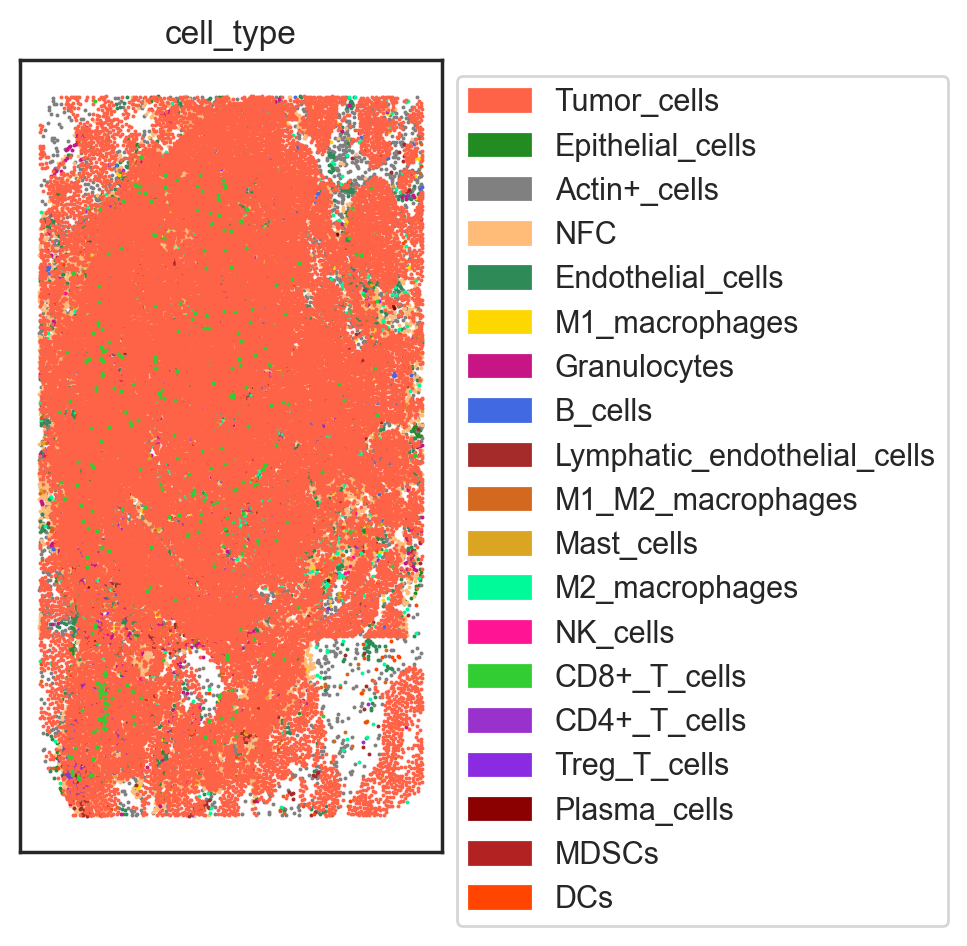

In [70]:
sm.pl.spatial_scatterPlot(adata, colorBy="cell_type", x_coordinate="Cell Center X", y_coordinate="Cell Center Y", topLayer=["Tumor_cells", "CD8+_T_cells"], s=2, subset=long_term, imageid="exp_name", customColors=cell_colors)
sm.pl.spatial_scatterPlot(adata, colorBy="cell_type", x_coordinate="Cell Center X", y_coordinate="Cell Center Y", topLayer=["Tumor_cells", "CD8+_T_cells"], s=2, subset=short_term, imageid="exp_name", customColors=cell_colors)

In [119]:
long_term_zscore = ["zscore_" + roi for roi in ["Run141_ROI11", "Run141_ROI19", "Run141_ROI8", "Run141_ROI17"]]
short_term_zscore = ["zscore_" + roi for roi in ["Run141_ROI16", "Run141_ROI7", "Run141_ROI15", "Run141_ROI23"]]


In [121]:
boxplot_data = heatmap_data.melt(var_name='variable', value_name='value', ignore_index=False)
boxplot_data = boxplot_data.filter(like = "CD8+_T_cells-Tumor_cells", axis=0)
boxplot_data["group"] = np.where(boxplot_data["variable"].isin(long_term_zscore), "Long_term", "Short_term")
boxplot_data


,variable,value,group
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI11,-15.521816,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI19,-8.852351,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI8,-28.027726,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI17,-14.573462,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI16,0.350344,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI7,1.055972,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI15,1.813534,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI23,1.628872,Short_term


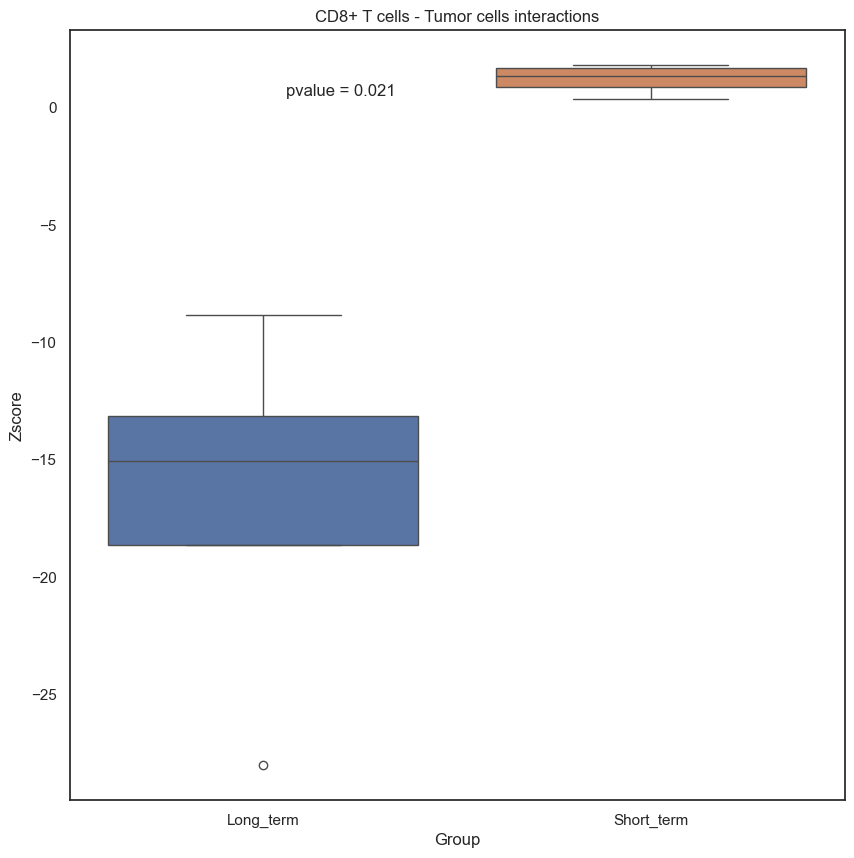

In [136]:
#build a boxplot based on boxplt_data based on matplot
#add the jitter to the boxplot
plt.figure(figsize=(10, 10))
sns.boxplot(x='group', y='value', hue='group', data=boxplot_data)
#add title to box plot and labels
plt.title('CD8+ T cells - Tumor cells interactions')
plt.xlabel('Group')
plt.ylabel('Zscore')
#calculate pvalue based on wilcox and add it to the plot
pvalue = sp.stats.ranksums(boxplot_data[boxplot_data["group"] == "Long_term"]["value"], boxplot_data[boxplot_data["group"] == "Short_term"]["value"]).pvalue.round(3)
plt.text(0.2, 0.5, "pvalue = " + str(pvalue), fontsize=12, ha='center')
plt.show()

In [147]:
adata_long = adata[adata.obs["exp_name"].isin(["Run141_ROI11", "Run141_ROI19", "Run141_ROI8", "Run141_ROI17"])]
adata_short = adata[adata.obs["exp_name"].isin(["Run141_ROI16", "Run141_ROI7", "Run141_ROI15", "Run141_ROI23"])]

In [153]:
adata = sm.tl.spatial_distance(adata, x_coordinate='Cell Center X', y_coordinate='Cell Center Y', imageid='exp_name', subset=None, verbose=True, label='scimap_distance', phenotype='cell_type')

Processing Image: Run141_ROI11
Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run141_ROI19
Processing Image: Run141_ROI8
Processing Image: Run141_ROI17
Processing Image: Run141_ROI15
Processing Image: Run141_ROI23


In [150]:
adata_long = sm.tl.spatial_distance(adata_long, x_coordinate='Cell Center X', y_coordinate='Cell Center Y', imageid='exp_name', subset=None, verbose=True, label='scimap_distance', phenotype='cell_type')
adata_short = sm.tl.spatial_distance(adata_short, x_coordinate='Cell Center X', y_coordinate='Cell Center Y', imageid='exp_name', subset=None, verbose=True, label='scimap_distance', phenotype='cell_type')

Processing Image: Run141_ROI11
Processing Image: Run141_ROI19
Processing Image: Run141_ROI8
Processing Image: Run141_ROI17
Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run141_ROI15
Processing Image: Run141_ROI23


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/scimap/tools/spatial_distance.py:143: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



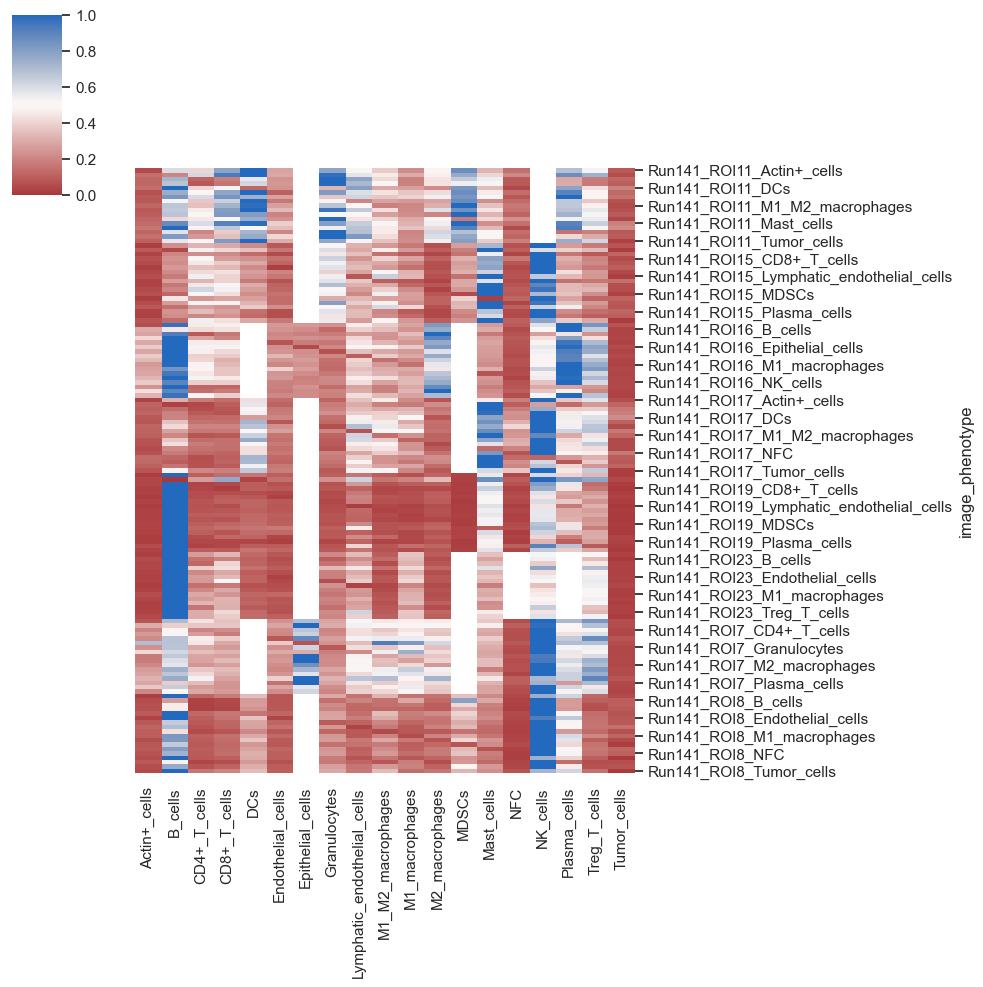

In [157]:
sm.pl.spatial_distance(adata, phenotype="cell_type", imageid="exp_name", spatial_distance='scimap_distance', heatmap_summarize=False)

In [1]:
sm.pl.spatial_distance(adata_long, phenotype="cell_type", imageid="exp_name", spatial_distance='scimap_distance')
sm.pl.spatial_distance(adata_short, phenotype="cell_type", imageid="exp_name", spatial_distance='scimap_distance')


NameError: name 'sm' is not defined

In [22]:
#Proportion of Granulocytes to CD4+

proportion = adata.obs.groupby(["outcome_group", "exp_name", "cell_type"]).size().unstack().fillna(0)[["Granulocytes", "CD4+_T_cells", "CD8+_T_cells"]]
#calculate total number of cells
proportion["total"] = proportion.sum(axis=1)
proportion["T_cells"] = proportion["CD4+_T_cells"] + proportion["CD8+_T_cells"]
#calculate the proportion of Granulocytes to T_cells
proportion["Granulocytes_to_T_cells"] = proportion["Granulocytes"] / proportion["T_cells"]
#normalize it by the total number of cells
proportion["Granulocytes_to_T_cells"] = (proportion["Granulocytes_to_T_cells"] / proportion["total"]) * 1000
proportion = proportion.reset_index()
#stabalizze it
proportion["Granulocytes_to_T_cells"] = np.log1p(proportion["Granulocytes_to_T_cells"])
proportion

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_6039/3962860245.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



cell_type,outcome_group,exp_name,Granulocytes,CD4+_T_cells,CD8+_T_cells,total,T_cells,Granulocytes_to_T_cells
0,long_term survival,Run141_ROI1,0,0,0,0,0,NaN
1,long_term survival,Run141_ROI3,0,0,0,0,0,NaN
2,long_term survival,Run141_ROI4,0,0,0,0,0,NaN
3,long_term survival,Run141_ROI7,0,0,0,0,0,NaN
4,long_term survival,Run141_ROI8,106,1434,530,2070,1964,0.025739
5,long_term survival,Run141_ROI11,34,209,72,315,281,0.325061
6,long_term survival,Run141_ROI14,0,0,0,0,0,NaN
7,long_term survival,Run141_ROI15,0,0,0,0,0,NaN
8,long_term survival,Run141_ROI16,0,0,0,0,0,NaN
9,long_term survival,Run141_ROI17,2077,1520,1291,4888,2811,0.140772


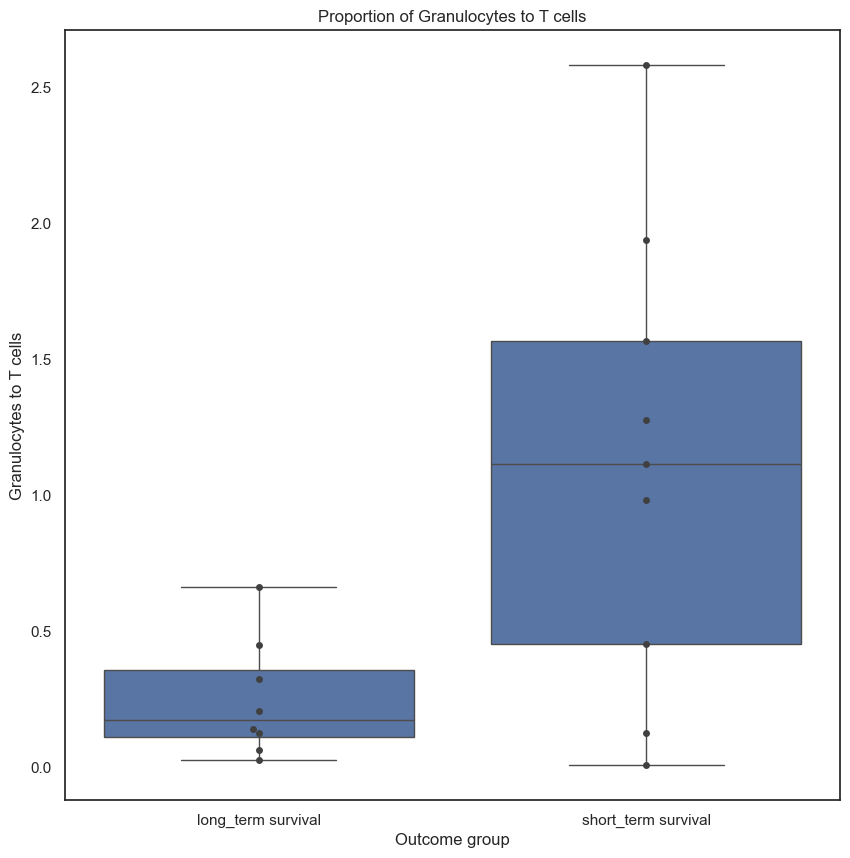

In [25]:
#plotting boxplot
plt.figure(figsize=(10, 10))
sns.boxplot(x="outcome_group", y="Granulocytes_to_T_cells", data=proportion)
sns.swarmplot(x="outcome_group", y="Granulocytes_to_T_cells", data=proportion, color=".25", dodge=True, legend=False, size=5)
plt.title("Proportion of Granulocytes to T cells")
plt.ylabel("Granulocytes to T cells")
plt.xlabel("Outcome group")
plt.show()

array([[ 3.364911  , -0.05504028,  1.4204489 , ..., -0.625759  ,
         0.6410527 ,  0.8886294 ],
       [ 0.24970348, -1.0339532 ,  1.7215923 , ...,  0.3054985 ,
         0.22106291,  0.9939115 ],
       [ 1.27325   , -1.2512585 ,  2.1407115 , ...,  0.30332476,
         0.21192957,  0.66310835],
       ...,
       [-0.99729556, -0.4536652 , -1.1325684 , ...,  0.93053603,
         0.14767537,  1.3336124 ],
       [-1.2233319 , -0.45298016, -1.4159251 , ...,  1.2389164 ,
         0.16221976,  1.4863019 ],
       [-1.1030433 , -0.42845234, -1.2105902 , ...,  0.426439  ,
        -0.08300974,  0.6062372 ]], dtype=float32)

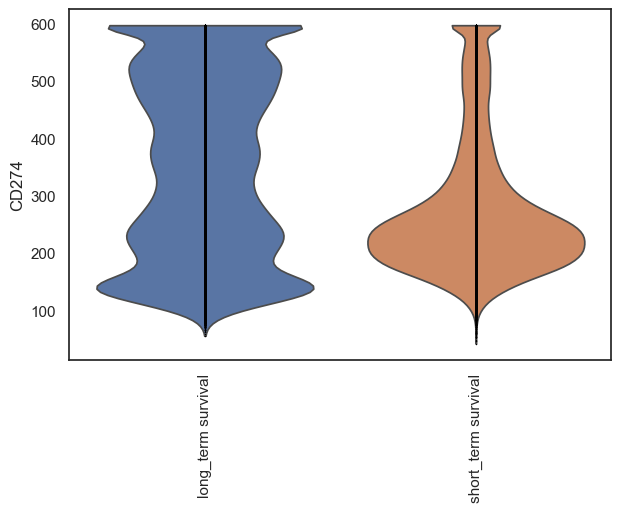

In [63]:
sc.pl.violin(adata, keys="CD274", groupby='outcome_group', jitter=0.001, rotation=90, size=1)
#Calculate pvalues

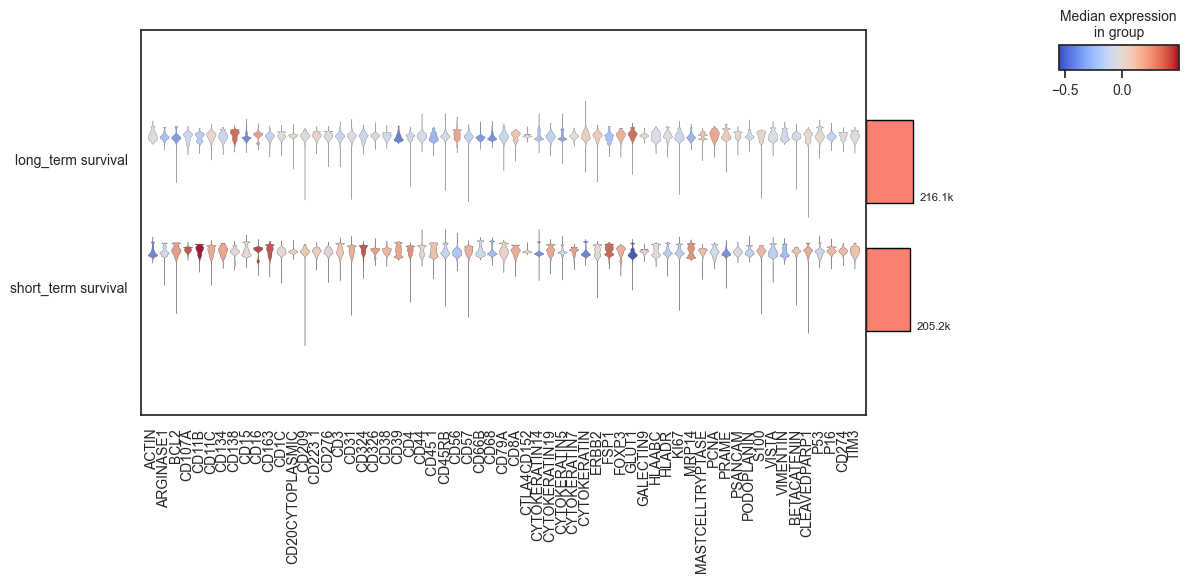

In [62]:
plot = sc.pl.stacked_violin(adata, adata.var_names, groupby='outcome_group', cmap='coolwarm', use_raw=False, density_norm='area', figsize=(12, 5), return_fig=True)
plot.add_totals()
axes = plot.get_axes()
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 7, current_pos[1] - 3))
axes['color_legend_ax'].set_position([0.89, 0.80, 0.1, 0.05])
fig = axes['mainplot_ax'].figure

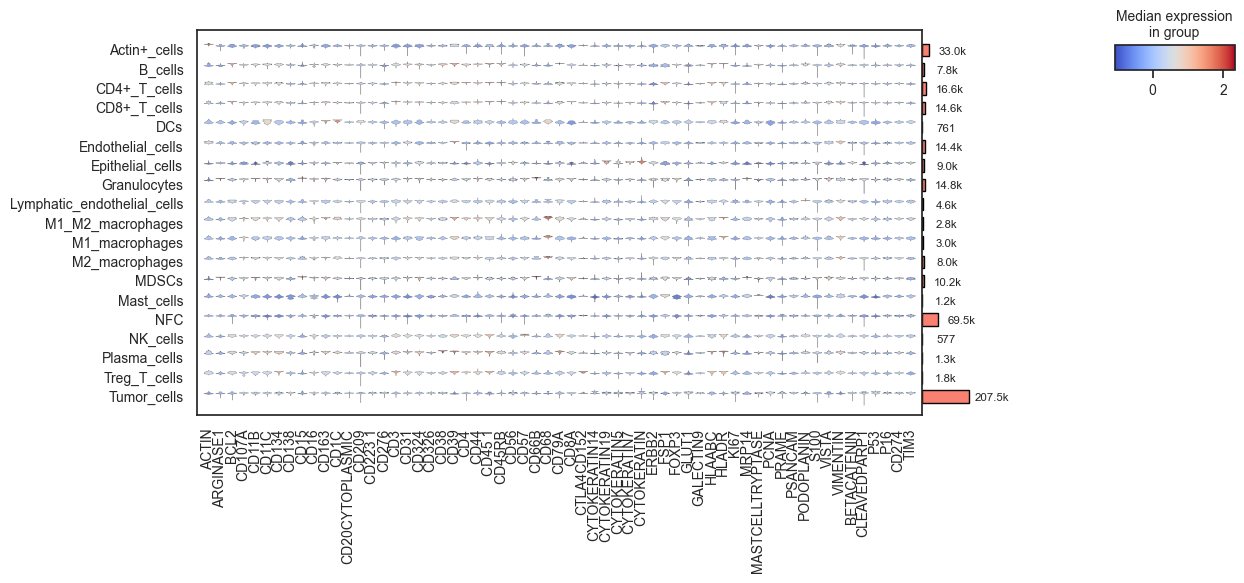

In [61]:
plot = sc.pl.stacked_violin(adata, adata.var_names, groupby='cell_type', cmap='coolwarm', use_raw=False, density_norm='area', figsize=(12, 5), return_fig=True)
plot.add_totals()
axes = plot.get_axes()
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 7, current_pos[1] - 3))
axes['color_legend_ax'].set_position([0.89, 0.80, 0.1, 0.05])
fig = axes['mainplot_ax'].figure